# Regressão — Otimização Bayesiana com Optuna

Otimizamos os hiperparâmetros do `RandomForestRegressor` e do `XGBRegressor` usando o
[Optuna](https://optuna.org/) (otimização bayesiana via TPE), avaliando cada combinação por
validação cruzada **no conjunto de treino**. O conjunto de teste só é usado no final, uma
única vez, para a avaliação do modelo campeão.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import optuna
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

sns.set_theme(style='whitegrid')
optuna.logging.set_verbosity(optuna.logging.WARNING)  # silencia o log de cada trial; o resultado final já resume tudo
RANDOM_STATE = 42  # mesmo valor dos notebooks 02 e 03, para o split de treino/teste continuar idêntico


## 2. Carregar dados e separar treino/teste

In [2]:
df = pd.read_csv('../data/pib_municipios.csv')

ALVO = 'pib_per_capita'
FEATURES_NUM = ['populacao', 'participacao_agropecuaria', 'participacao_industria',
                'participacao_servicos', 'participacao_administracao_publica']
FEATURES_CAT = ['uf', 'regiao']

X = df[FEATURES_NUM + FEATURES_CAT]
y = df[ALVO]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

preprocessador = ColumnTransformer(transformers=[
    ('num', StandardScaler(), FEATURES_NUM),
    ('cat', OneHotEncoder(handle_unknown='ignore'), FEATURES_CAT),
])

# mesmos 5 folds do 03_Comparacao_Modelos_CV.ipynb — garante que a otimização é avaliada
# exatamente com o mesmo protocolo usado para escolher o XGBoost como favorito
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


## 3. Otimização — RandomForestRegressor

A cada *trial*, o Optuna propõe um conjunto de hiperparâmetros, treinamos com validação
cruzada no treino e retornamos o RMSE médio (a minimizar).

In [3]:
# faixas de busca escolhidas para cobrir do "raso e rápido" ao "profundo e lento" sem explodir o
# tempo de otimização (cada trial já roda 5 folds inteiros); TPESampler porque é mais eficiente que
# busca aleatória/grid quando cada avaliação é cara — ele aprende com os trials anteriores
def objetivo_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 600),
        'max_depth': trial.suggest_int('max_depth', 3, 25),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
    }
    modelo = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **params)
    pipe = Pipeline([('preprocessador', preprocessador), ('modelo', modelo)])
    rmse_scores = -cross_val_score(pipe, X_train, y_train, cv=kfold,
                                    scoring='neg_root_mean_squared_error', n_jobs=-1)
    return rmse_scores.mean()  # Optuna minimiza o retorno da função — por isso o RMSE já sai com sinal positivo aqui

estudo_rf = optuna.create_study(direction='minimize', study_name='rf_pib_per_capita',
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
estudo_rf.optimize(objetivo_rf, n_trials=40, show_progress_bar=True)

print('Melhor RMSE (CV):', estudo_rf.best_value)
print('Melhores parâmetros:', estudo_rf.best_params)


  0%|          | 0/40 [00:00<?, ?it/s]

Melhor RMSE (CV): 14684.992257145848
Melhores parâmetros: {'n_estimators': 235, 'max_depth': 18, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': None}


**Resultado:** RMSE (CV) cai de R$ 15.610 (RandomForest padrão, notebook 03) para **R$ 14.685**
— uma melhora de ~6%, com `min_samples_leaf=3` e `max_features=None` entre os parâmetros vencedores
(árvores um pouco mais profundas e sem restringir o número de features por split). É uma melhora
real, mas modesta — o RandomForest continua atrás do XGBoost mesmo depois de otimizado.

## 4. Otimização — XGBRegressor

In [4]:
# learning_rate e reg_lambda em escala log (log=True): esses parâmetros afetam o resultado de forma
# multiplicativa, não aditiva — buscar em escala log dá ao Optuna mais resolução na faixa "baixa"
# (0.01 a 0.1), onde a maior parte dos bons valores costuma estar
def objetivo_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 800),
        'max_depth': trial.suggest_int('max_depth', 2, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    }
    modelo = XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0, **params)
    pipe = Pipeline([('preprocessador', preprocessador), ('modelo', modelo)])
    rmse_scores = -cross_val_score(pipe, X_train, y_train, cv=kfold,
                                    scoring='neg_root_mean_squared_error', n_jobs=-1)
    return rmse_scores.mean()

estudo_xgb = optuna.create_study(direction='minimize', study_name='xgb_pib_per_capita',
                                  sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
estudo_xgb.optimize(objetivo_xgb, n_trials=40, show_progress_bar=True)

print('Melhor RMSE (CV):', estudo_xgb.best_value)
print('Melhores parâmetros:', estudo_xgb.best_params)


  0%|          | 0/40 [00:00<?, ?it/s]

Melhor RMSE (CV): 11779.490881802509
Melhores parâmetros: {'n_estimators': 625, 'max_depth': 7, 'learning_rate': 0.01400985974088348, 'subsample': 0.8762233492410318, 'colsample_bytree': 0.9193079298235876, 'min_child_weight': 4, 'reg_lambda': 4.1169677880316184}


**Resultado:** RMSE (CV) cai de R$ 13.124 (XGBoost padrão, notebook 03) para **R$ 11.779** —
uma melhora de ~10%, maior que a do RandomForest. O Optuna convergiu para `learning_rate` baixo
(≈0,014) combinado com `n_estimators` alto (625): é o padrão clássico "passos pequenos, muitas
árvores", que tende a generalizar melhor que poucos passos grandes, ao custo de mais tempo de
treino. **Escolha:** XGBoost otimizado é o candidato a modelo final — vence em RMSE médio de CV
tanto antes quanto depois do tuning.

## 5. Histórico de otimização e importância dos hiperparâmetros

C:\Users\edd-j\AppData\Local\Temp\ipykernel_10208\4285495516.py:3: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = plot_optimization_history(estudo_rf)


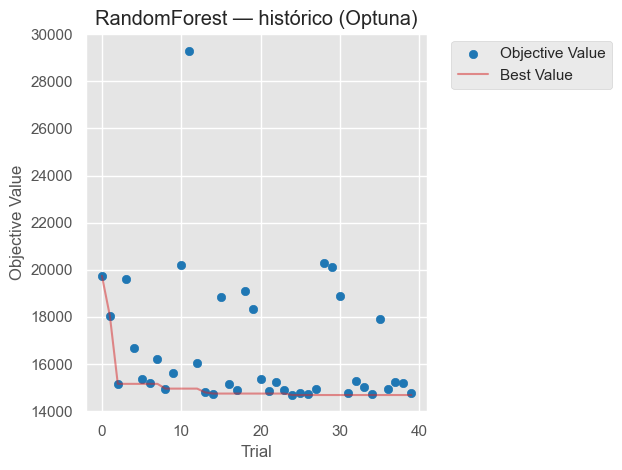

C:\Users\edd-j\AppData\Local\Temp\ipykernel_10208\4285495516.py:9: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = plot_optimization_history(estudo_xgb)


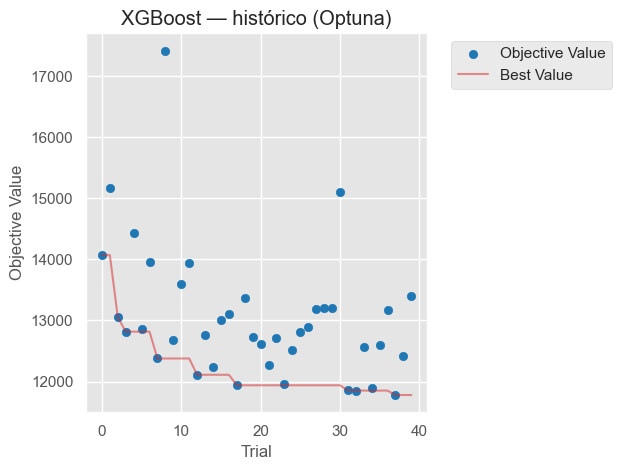

In [5]:
# histórico mostra o RMSE de cada trial ao longo do tempo — uma curva descendente e depois
# "achatada" indica que o Optuna convergiu e mais trials provavelmente não ajudariam muito
ax = plot_optimization_history(estudo_rf)
ax.set_title('RandomForest — histórico (Optuna)')
plt.tight_layout()
plt.savefig('../reports/09a_optuna_historico_rf.png', dpi=120)
plt.show()

ax = plot_optimization_history(estudo_xgb)
ax.set_title('XGBoost — histórico (Optuna)')
plt.tight_layout()
plt.savefig('../reports/09b_optuna_historico_xgb.png', dpi=120)
plt.show()


C:\Users\edd-j\AppData\Local\Temp\ipykernel_10208\4022326000.py:6: ExperimentalWarning: plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ax = plot_param_importances(estudo_rf)


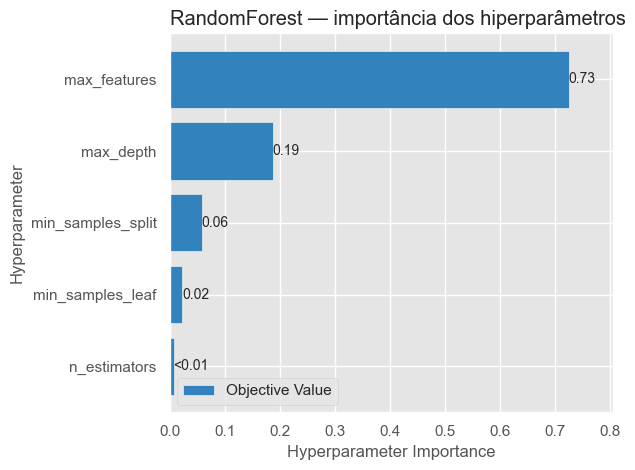

C:\Users\edd-j\AppData\Local\Temp\ipykernel_10208\4022326000.py:12: ExperimentalWarning: plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ax = plot_param_importances(estudo_xgb)


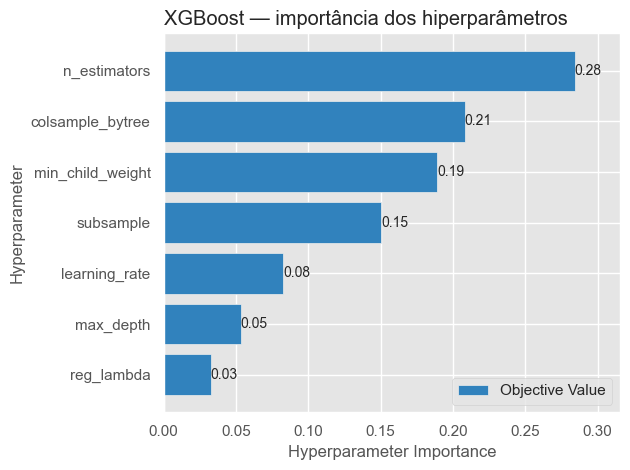

In [6]:
# importância = quanto cada hiperparâmetro, isoladamente, explica a variação do RMSE entre os
# trials — ajuda a saber onde vale a pena refinar a busca numa próxima rodada
# loc="left" porque é assim que o optuna já define o título dessa função — usar o padrão (center)
# criaria um segundo título por cima do primeiro, sem apagar o original (foi o que gerou a
# sobreposição de texto na primeira versão deste notebook)
ax = plot_param_importances(estudo_rf)
ax.set_title('RandomForest — importância dos hiperparâmetros', loc='left')
plt.tight_layout()
plt.savefig('../reports/10a_optuna_importancia_rf.png', dpi=120)
plt.show()

ax = plot_param_importances(estudo_xgb)
ax.set_title('XGBoost — importância dos hiperparâmetros', loc='left')
plt.tight_layout()
plt.savefig('../reports/10b_optuna_importancia_xgb.png', dpi=120)
plt.show()


## 6. Escolher o campeão e avaliar no teste (uma única vez)

In [7]:
# compara os dois modelos já otimizados pelo mesmo critério usado durante a busca (RMSE médio de CV)
candidatos = {
    'RandomForest_otimizado': (RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **estudo_rf.best_params),
                                estudo_rf.best_value),
    'XGBoost_otimizado': (XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0, **estudo_xgb.best_params),
                           estudo_xgb.best_value),
}

for nome, (_, rmse_cv) in candidatos.items():
    print(f'{nome:22s} | RMSE médio (CV) = {rmse_cv:,.2f}')

melhor_nome = min(candidatos, key=lambda n: candidatos[n][1])
melhor_modelo, _ = candidatos[melhor_nome]
print('\nModelo campeão:', melhor_nome)


RandomForest_otimizado | RMSE médio (CV) = 14,684.99
XGBoost_otimizado      | RMSE médio (CV) = 11,779.49

Modelo campeão: XGBoost_otimizado


In [8]:
pipeline_final = Pipeline([
    ('preprocessador', preprocessador),
    ('modelo', melhor_modelo),
])
pipeline_final.fit(X_train, y_train)  # agora sim treina com TODO o treino, não só 4 dos 5 folds

pred_teste = pipeline_final.predict(X_test)

# única vez que o conjunto de teste é usado neste projeto — garante uma estimativa de erro sem viés
rmse = mean_squared_error(y_test, pred_teste, squared=False)
mae = mean_absolute_error(y_test, pred_teste)
r2 = r2_score(y_test, pred_teste)

print(f'Avaliação final no conjunto de teste — {melhor_nome}')
print(f'RMSE = {rmse:,.2f}')
print(f'MAE  = {mae:,.2f}')
print(f'R2   = {r2:.3f}')


Avaliação final no conjunto de teste — XGBoost_otimizado
RMSE = 22,853.66
MAE  = 3,944.09
R2   = 0.710


C:\Users\edd-j\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


**Resultado:** RMSE de teste (**R$ 22.854**) ficou bem acima do RMSE médio de CV do XGBoost
otimizado (**R$ 11.779**) — quase o dobro. Antes de comemorar o R² de CV (0,896) ou de descartar o
modelo pelo R² de teste (0,710), vale entender por quê:

- O **MAE mal se move**: R$ 3.972 na CV (notebook 03, XGBoost padrão) contra **R$ 3.944** no teste
  final. Ou seja, o erro *típico* (mediana dos casos) é praticamente igual — o modelo não piorou
  no geral.
- O RMSE é sensível a erros grandes ao quadrado. Com um alvo tão assimétrico (skew ≈ 7,9, EDA
  seção 4) e só ~1.100 municípios no teste, basta **alguns municípios de mineração/petróleo**
  caírem no split de teste para o RMSE disparar — mesmo que o modelo acerte razoavelmente a
  maioria dos outros 1.095 municípios.
- Isso não é um bug nem um sinal de que a otimização foi inútil (o Optuna genuinamente melhorou o
  RMSE de CV de R$ 13.124 para R$ 11.779). É a variância de amostragem de um único split de teste
  encontrando a cauda longa da distribuição do alvo.

**O que fazer diferente numa próxima iteração:** testar `log1p(pib_per_capita)` como alvo (hipótese
já registrada na EDA) para reduzir a influência desses outliers no RMSE, ou reportar métricas
robustas a outliers (MAE, MedAE) com o mesmo peso que o RMSE ao comparar modelos.

## 7. Previsto vs. real e resíduos (modelo final)

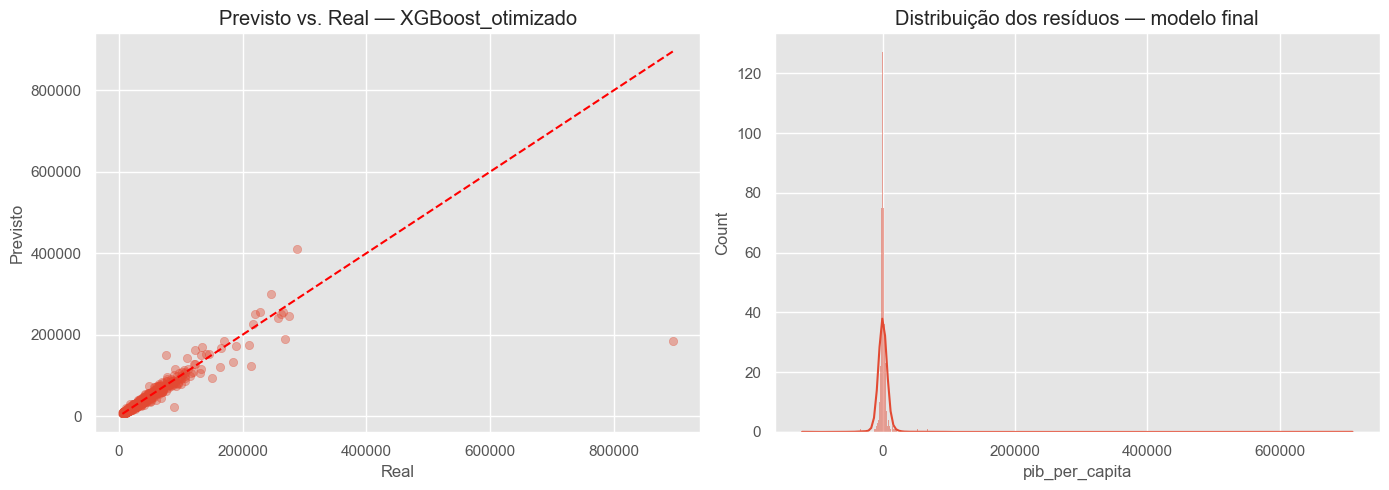

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# os pontos mais distantes da linha vermelha aqui devem ser, em boa parte, os mesmos municípios de
# mineração identificados na EDA (célula 14) — vale conferir visualmente essa hipótese
axes[0].scatter(y_test, pred_teste, alpha=0.4)
lim = [y_test.min(), y_test.max()]
axes[0].plot(lim, lim, color='red', linestyle='--')
axes[0].set_xlabel('Real')
axes[0].set_ylabel('Previsto')
axes[0].set_title(f'Previsto vs. Real — {melhor_nome}')

residuos = y_test - pred_teste
sns.histplot(residuos, kde=True, ax=axes[1])
axes[1].set_title('Distribuição dos resíduos — modelo final')

plt.tight_layout()
plt.savefig('../reports/11_modelo_final_previsto_vs_real.png', dpi=120)
plt.show()


**Resultado:** o padrão visual é parecido com o do baseline (notebook 02): a esmagadora maioria
dos municípios cola na diagonal, com um único ponto isolado bem longe dela — de novo,
**Canaã dos Carajás-PA** (real R$ 894.763). Mas vale comparar com o baseline número a número: o
RandomForest simples previa R$ 387.518 pra esse município (erro de R$ 507 mil); o XGBoost
otimizado prevê R$ 184.433 — um erro ainda **maior**, de R$ 710 mil. A otimização de
hiperparâmetros piorou a previsão desse outlier específico, mesmo melhorando o modelo no geral.

Isso aparece no histograma de resíduos, à direita: o pico perto de zero é mais alto e mais estreito
que o do baseline (85,7% dos municípios com erro abaixo de R$ 5 mil, contra 82,9% no baseline; erro
**mediano** de apenas R$ 1.498), mas a cauda à direita se estica ainda mais longe, e a assimetria
dos resíduos sobe de 22,8 (baseline) para **26,9**.

**Como interpretar isso:** o Optuna otimizou o modelo para minimizar o RMSE médio de validação
cruzada — e conseguiu: o caso *típico* ficou nitidamente melhor (erro mediano de R$ 1.498 é ótimo).
Mas RMSE é dominado pelos poucos erros gigantes, e nada no processo de otimização foi desenhado
especificamente para lidar com outliers tão extremos quanto Canaã dos Carajás — o modelo nunca viu,
no treino, um caso parecido o bastante para calibrar essa magnitude. É a mesma conclusão a que o
SHAP chega no notebook 05, por um caminho completamente diferente (explicabilidade em vez de
resíduos): a limitação não é de lógica do modelo, é de falta de exemplos extremos no treino.

## 8. Salvar o modelo final

In [10]:
# salva o pipeline completo (pré-processador + XGBoost otimizado) — pronto para receber dados
# novos em formato bruto (mesmas colunas de X) e devolver a previsão de PIB per capita
joblib.dump(pipeline_final, '../models/modelo_final.joblib')
print(f'Modelo final ({melhor_nome}) salvo em ../models/modelo_final.joblib')


Modelo final (XGBoost_otimizado) salvo em ../models/modelo_final.joblib


## 9. Resumo do projeto

| Etapa | Notebook | Resultado |
|---|---|---|
| EDA | `01_EDA.ipynb` | Alvo assimétrico (skew ≈ 7,9); `participacao_industria` (+0,45) e `participacao_administracao_publica` (−0,55) são as features mais correlacionadas; Sul lidera em mediana de PIB per capita |
| Baseline | `02_Baseline.ipynb` | LinearRegression R² 0,382 → RandomForest R² 0,835 |
| Comparação + CV | `03_Comparacao_Modelos_CV.ipynb` | XGBoost vence com RMSE R$ 13.124 (CV) e é o mais estável entre folds |
| Otimização | `04_Otimizacao_Optuna.ipynb` | XGBoost otimizado: RMSE R$ 11.779 (CV) → RMSE R$ 22.854 / MAE R$ 3.944 / R² 0,710 (teste) |

O salto entre o RMSE de CV e o RMSE de teste (seção 6 acima) é o principal ponto de atenção deste
projeto — não porque o modelo "piorou", mas porque o alvo assimétrico faz o RMSE de um único split
de teste ser uma métrica ruidosa. O MAE, mais robusto a outliers, ficou estável do início ao fim
(~R$ 3.9 mil), o que é a leitura mais confiável do erro típico do modelo em produção.

O modelo final está salvo em `../models/modelo_final.joblib` e pode ser recarregado com
`joblib.load(...)` para gerar novas previsões.
